# Implementing ANNs with TensorFlow - Homework 08 (Group 4)

## Assignment: Autoencoders

### Load the dataset



In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.manifold import TSNE

# load the data
(train_ds, test_ds), ds_info = tfds.load("mnist", split=["train", "test"], as_supervised=True, with_info=True)

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to ~/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


### Prepare the dataset

In [2]:
def prepare_data(mnist, mode, batch_size=32, noise_factor=0.3):
  """
  This function is used to prepare the raw data for training and testing.
  Returns a batched dataset containing noisy images and their original counterparts from the MNIST dataset.

  Arguments:
  mnist -- (a subset of) the MNIST dataset
  mode -- determines whether we want to shuffle the data or not
  batch_size -- denotes the batch size (default is 32)
  noise_factor -- denotes the gravity of the added noise (default is 0.3)
  """
  # drop the original target labels and create image-to-image tuples
  mnist = mnist.map(lambda img, _: (img, img))
  # convert images to float32 data type
  mnist = mnist.map(lambda img, target: (tf.cast(img, tf.float32), tf.cast(target, tf.float32)))
  # add noise to the training image
  mnist = mnist.map(lambda img, target: (img + noise_factor * tf.random.normal(shape=img.shape, mean=0., stddev=100.), target))
  # helper function to normalize the data
  normalize = lambda x: 2*(x-tf.reduce_min(x))/(tf.reduce_max(x)-tf.reduce_min(x))-1.
  # project the pixel values into range [-1, 1]
  mnist = mnist.map(lambda img, target: ((normalize(img), normalize(target))))
  # cache progress into memory
  mnist = mnist.cache()
  # shuffle the data in training mode
  # do not when we want to create a different dataset for TSNE later on
  if mode == "training":
    mnist = mnist.shuffle(1000)
  # batch and prefetch the data
  mnist = mnist.batch(batch_size)
  mnist = mnist.prefetch(tf.data.AUTOTUNE)
  
  return mnist

In [3]:
# apply preprocessing to training and test data
train_data = prepare_data(mnist=train_ds, mode="training")
test_data = prepare_data(mnist=test_ds, mode="training")

In [4]:
# check the respective shapes of noisy and original images
for img, target in train_data.take(1):
  print(img.shape)
  print(target.shape)

(32, 28, 28, 1)
(32, 28, 28, 1)


In [5]:
def plot_images(data, num_images):
  """
  A function to display noisy images of the augmented MNIST dataset and their corresponding targets.

  Arguments:
  data -- the prepared training or test data
  num_images -- denotes the number of images we want to display
  """
  fig, axes = plt.subplots(nrows=2, ncols=num_images, sharex=True, figsize=(8, 4))
  # plot given number of images 
  for i, (img, target) in enumerate(train_data.take(num_images)):
    # upper row shows the noisy images
    axes[0, i].imshow(img[0].numpy().reshape((28,28)))
    axes[0, i].axis("off")
    # bottom row shows the target images
    axes[1, i].imshow(target[0].numpy().reshape((28,28)))
    axes[1, i].axis("off")
    
  plt.tight_layout()
  plt.show()

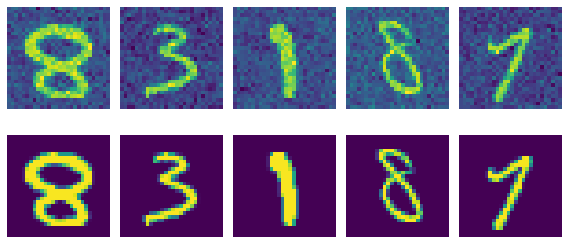

In [6]:
# show some examples after the data preprocessing
plot_images(train_data, 5)

### The model

#### Encoder

In [7]:
class Encoder(tf.keras.Model):
  """
  The encoder embeds the image into a lower-dimensional latent representation.
  """
  def __init__(self, latent_dim):
    """
    The encoding layers first reduce the image sizes to 7x7 and then create a 
    vector embedding with the given number of latent dimensions.

    Arguments:
    latent_dim -- denotes the number of latent dimensions of the data embedding
    """
    # call the parent constructor
    super().__init__()
    # instantiate the encoder layers
    self.encoding_layers = [tf.keras.layers.Conv2D(filters=24, kernel_size=3, strides=2, padding="same", activation="relu"),
                            tf.keras.layers.Conv2D(filters=48, kernel_size=3, strides=2, padding="same", activation="relu"),
                            tf.keras.layers.Flatten(),
                            tf.keras.layers.Dense(latent_dim)]

  @tf.function
  def call(self, input):
    """
    This function calls the encoder on an image and returns a compressed embedding.

    Arguments:
    input -- denotes the input images
    """
    # feed the image through the encoder
    output = self.encoding_layers[0](input)
    for layer in self.encoding_layers[1:]:
      output = layer(output)

    return output

#### Decoder

In [8]:
class Decoder(tf.keras.Model):
  """
  The decoder converts the latent representation back to an image.
  """
  def __init__(self, batch_size):
    """
    The decoding layers pick up the compressed image embedding and transpose it back to 
    a 28x28 image.

    batch_size -- denotes the batch size of the prepared dataset
    """
    super().__init__()
    # instantiate the decoder layers
    self.decoding_layers = [tf.keras.layers.Dense(units=7*7*batch_size, activation="relu"), 
                            tf.keras.layers.Reshape(target_shape=(7, 7, batch_size)),
                            tf.keras.layers.Conv2DTranspose(filters=48, kernel_size=3, strides=2, padding="same", activation="relu"),
                            tf.keras.layers.Conv2DTranspose(filters=24, kernel_size=3, strides=2, padding="same", activation="relu"),
                            tf.keras.layers.Conv2DTranspose(filters=1, kernel_size=3, strides=1, padding="same")]

  @tf.function
  def call(self, embedding):
    """
    This function calls the decoder on a latent representation of an image returns its reconstruction.

    Arguments:
    embedding -- denotes the compressed representation of an image
    """
    # feed the embedding through the decoder
    output = self.decoding_layers[0](embedding)
    for layer in self.decoding_layers[1:]:
      output = layer(output)

    return output

#### Autoencoder

In [9]:
class Autoencoder(tf.keras.Model):
  """
  The autoencoder learns an effective data embedding to regenerate its input as its output.
  """
  def __init__(self, latent_dim, alpha, batch_size):
    """
    The constructor initializes the encoder and decoder alongside the loss function,
    optimizer, and the loss metric.

    Arguments:
    latent_dim -- denotes the number of latent dimensions of the data embedding
    alpha -- denotes the learning rate
    batch_size -- denotes the batch size of the prepared dataset
    """
    super().__init__()
    # use MSE as loss function
    self.loss_function = tf.keras.losses.MeanSquaredError()
    # use Adam as our optimizer
    self.optimizer = tf.keras.optimizers.Adam(learning_rate=alpha)
    # instantiate the loss metric
    self.loss_metric = tf.keras.metrics.Mean(name="loss")
    # instantiate the encoder
    self.encoder = Encoder(latent_dim)
    # instantiate the decoder
    self.decoder = Decoder(batch_size)

  @tf.function
  def call(self, input):
    """
    This function passes images through the encoder and decoder to create image reconstructions.

    Arguments:
    input -- denotes the input images
    """
    # feed the input images through the network
    embedding = self.encoder(input)
    output = self.decoder(embedding)

    return output

  @tf.function
  def train_step(self, input):
    """
    This function defines a step during the training process.

    Arguments:
    input -- the input tensors (noisy image, target image) to the model
    """
    # unpack the input
    img, target = input
    with tf.GradientTape() as tape:
      # create the prediction
      prediction = self(img, training=True)
      # calculate the loss
      loss = self.loss_function(target, prediction)
    # calculate the gradients
    gradients = tape.gradient(loss, self.trainable_variables)
    # apply the gradients
    self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
    # update the metric
    self.loss_metric.update_state(loss)

    return self.loss_metric.result()

  @tf.function
  def test_step(self, test_data):
    """
    A function to test how the model performs on the given data.

    Arguments:
    test_data -- the data used for testing
    """
    # unpack the data
    img, target = test_data
    # create prediction but do not backpropagate
    prediction = self(img, training=False)
    # calculate loss
    loss = self.loss_function(target, prediction)
    # update the loss metric
    self.loss_metric.update_state(loss)

    return self.loss_metric.result()

  def training(self, n_epochs, train_dataset, test_dataset):
    """
    Defines the training process of our neural network.

    Arguments:
    n_epochs -- the number of training epochs
    train_dataset -- denotes the training dataset
    test_dataset -- denotes the test dataset
    """
    print("Training progress: \n")

    # train for given number of epochs
    for epoch in range(n_epochs):
      print(f"Epoch {epoch}:")

      # train the network
      for data in tqdm.tqdm(train_data, position=0, leave=True):
        train_loss = self.train_step(data)
      
      print(f"Training loss: {train_loss}")

      # reset the loss metric
      self.loss_metric.reset_states()

      # test the network
      for data in test_dataset:
        test_loss = self.test_step(data)

      print(f"Test loss: {test_loss}\n")

      # again reset the loss metric
      self.loss_metric.reset_states()

### Training

In [10]:
# hyperparameter for the training process
EPOCHS = 10
ALPHA = 0.001
BATCH_SIZE = 32

# instantiate the Autoencoder class
autoencoder = Autoencoder(latent_dim=10, alpha=ALPHA, batch_size=BATCH_SIZE)
# train the autoencoder
autoencoder.training(n_epochs=EPOCHS, train_dataset=train_data, test_dataset=test_data)

Training progress: 

Epoch 0:


100%|██████████| 1875/1875 [01:19<00:00, 23.67it/s]


Training loss: 0.13015232980251312
Test loss: 0.07356594502925873

Epoch 1:


100%|██████████| 1875/1875 [01:01<00:00, 30.52it/s]


Training loss: 0.06996677070856094
Test loss: 0.06467315554618835

Epoch 2:


...

Training loss: 0.05490279197692871
Test loss: 0.05447614938020706

Epoch 8:


100%|██████████| 1875/1875 [01:01<00:00, 30.27it/s]


Training loss: 0.054104823619127274
Test loss: 0.053904980421066284

Epoch 9:


100%|██████████| 1875/1875 [01:01<00:00, 30.63it/s]


Training loss: 0.05348815396428108
Test loss: 0.054007142782211304



### Latent Space Analysis

In [11]:
# create another dataset with 1000 examples
tsne_ds = test_ds.take(1000)
# save the labels for plotting later on
img_labels = [label.numpy() for _, label in tsne_ds]
# preprocess the data, but do not shuffle it (so the labels will still be correct)
tsne_data = prepare_data(mnist=tsne_ds, mode="tsne")
# create embedding by passing the test data through the trained encoder
img_embedding = autoencoder.encoder.predict(tsne_data)

32/32 [==============================] - 0s 7ms/step


In [ ]:
# fit the data into a t-distributed stochastic neighbour embedding space and return that transformed output
tsne_embedding = TSNE(n_components=2, n_iter=1000,n_iter_without_progress=250).fit_transform(img_embedding)

In [13]:
def plot_tsne(tsne, labels):
  """
  A function to plot the TSNE results.

  Arguments:
  tsne -- the TSNE space of our image encodings
  labels -- denotes the target digits represented in the images
  """
  fig, ax = plt.subplots(figsize=(12, 12))
  # create a scatter plot of the embedding space
  scatter_plot = ax.scatter(tsne[:, 0], tsne[:, 1], c=labels, cmap="tab10")
  # create the legend
  legend = [str(digit) for digit in range(10)]
  ax.legend(handles=scatter_plot.legend_elements()[0], labels=legend)
  
  plt.show()

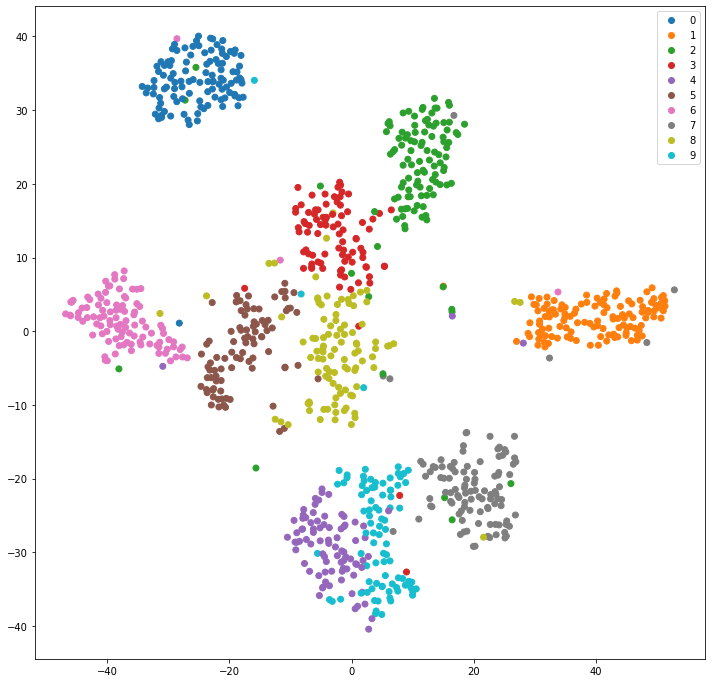

In [14]:
# plot the results
plot_tsne(tsne_embedding, labels=img_labels)

The t-SNE diagram does a decent, but not a perfect job of differentiating representation clusters.

We would probably expect some overlaps in the respective clusters between, for example, target numbers 0 and 6, 0 and 8, or 3 and 8. In this case, the assumption only holds for the latter case. In fact, the cluster representing images with target 0 is fairly separated from the rest. 

However, since distances between clusters do not necessarily have to mean anything (see *Distill* article), we should not interpret too much into the diagram.

### Interpolating between two images

We will look at the interpolation between images of the dataset with respective targets of 3 and 8, as there is some overlap in their representations within the embedding space above.

In [15]:
def plot_examples(data, num_rows, num_cols):
  """
  A function to display noisy images of the preprocessed MNIST dataset or their interpolations.

  Arguments:
  data -- the prepared training or test data
  num_rows -- denotes the number of rows we want to display
  num_cols -- denotes the number of columns we want to display
  """
  # display images in a plot grid with given number of rows and columns
  fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, sharex=True, figsize=(2*num_cols, 2*num_rows))
  for i, img in enumerate(data):
    # if there is only one row
    if num_rows == 1:
      axes[i].imshow(img)
      axes[i].axis("off")
    else:
      # derive respective row and column for the image
      row = int(i / num_cols)
      col = i % num_cols
      # show image
      axes[row, col].imshow(img)
      axes[row, col].axis("off")

  plt.tight_layout()
  plt.show()

In [16]:
# pull individual images from an image batch in the dataset
example_imgs = [img.numpy().reshape((28,28)) for img_batch, _ in tsne_data.take(1) for img in img_batch]

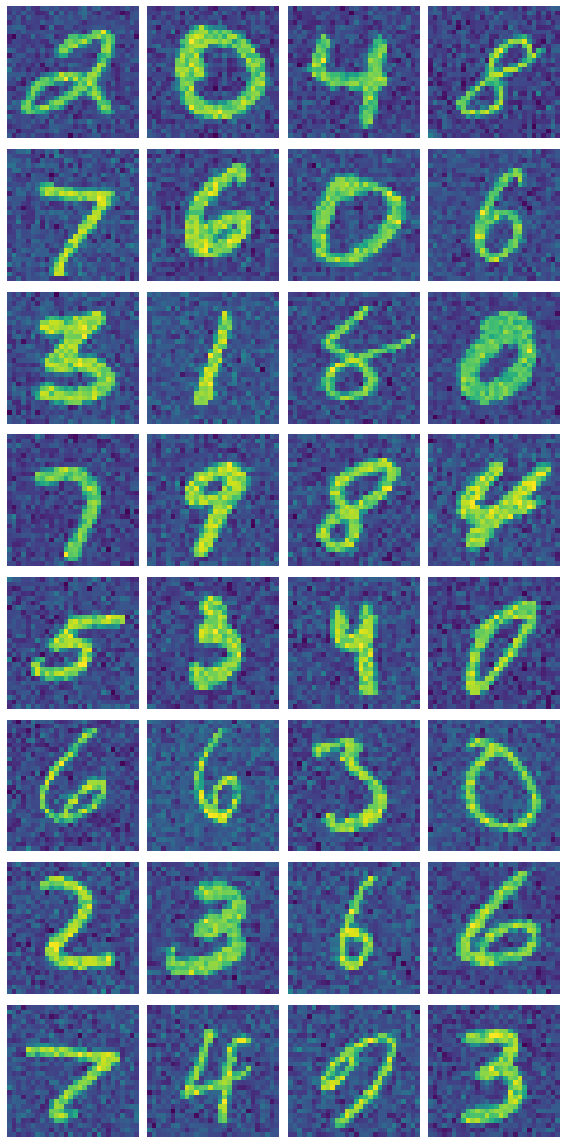

In [17]:
# plot these examples
plot_examples(example_imgs, 8, 4)

In [18]:
# create a latent representation for respective examples with target 3 and 8
img_target_3 = autoencoder.encoder.predict(tf.constant(example_imgs[31].reshape(1,28,28,1)))
img_target_8 = autoencoder.encoder.predict(tf.constant(example_imgs[14].reshape(1,28,28,1)))
# use the decoder to create predictions with varying degrees of the respective embedding vectors
interpolated_imgs = [autoencoder.decoder.predict((1-i)*img_target_3 + i*img_target_8) for i in np.linspace(0, 1, 8)]
# reshape the images so we can plot them
interpolated_imgs = [img.reshape((28, 28)) for img in interpolated_imgs]

1/1 [==============================] - 0s 16ms/step


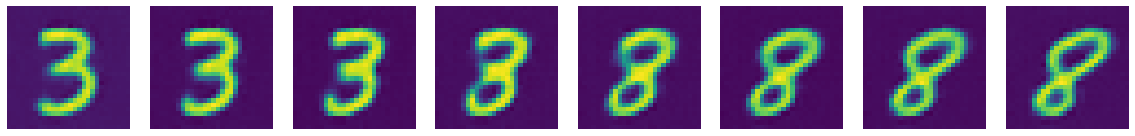

In [19]:
# plot the interpolated images
plot_examples(interpolated_imgs, 1, 8)